# 6. In this exercise, you will further analyze the Wage data set considered throughout this chapter.

In [39]:
!pip install ISLP

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns

Wage = load_data('Wage')
print(Wage.shape)
Wage.info()

(3000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        3000 non-null   int64   
 1   age         3000 non-null   int64   
 2   maritl      3000 non-null   category
 3   race        3000 non-null   category
 4   education   3000 non-null   category
 5   region      3000 non-null   category
 6   jobclass    3000 non-null   category
 7   health      3000 non-null   category
 8   health_ins  3000 non-null   category
 9   logwage     3000 non-null   float64 
 10  wage        3000 non-null   float64 
dtypes: category(7), float64(2), int64(2)
memory usage: 115.5 KB


## (a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial ft to the data.

### Result
Best d = 8.

### ANOVA 檢定
要小於 0.05 -> 顯著
| 模型比較      | P-value (Pr(>F))      |
|---------------|------------------------|
| d=2 vs d=1    | 5.95×10⁻³¹             |
| d=3 vs d=2    | 2.16×10⁻³              |
| d=4 vs d=3    | 5.68×10⁻²              |
| d=5 vs d=4    | 3.81×10⁻¹              |

- 2.16×10⁻³ < 0.05 => d3 比 d2 顯著
- 5.68×10⁻² > 0.05 => d4 比 d3 顯著
Best d = 3.

In [41]:
X = Wage['age'].values.reshape(-1, 1)
y = Wage['wage'].values

cv = KFold(n_splits=10, shuffle=True, random_state=34)
degrees = range(1, 16)
mse_scores = []

for d in degrees:
  poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=d)),
    ('linear', LinearRegression())
  ])

  scores = -cross_val_score(poly_pipeline, X, y, scoring='neg_mean_squared_error', cv=cv)
  mse_scores.append(scores.mean())

optimal_degree = degrees[np.argmin(mse_scores)]
min_mse = np.min(mse_scores)

for d, mse in zip(degrees, mse_scores):
  print(f"d={d}: MSE = {mse:.2f}")

print(f"\nBest: d = {optimal_degree}, MSE = {min_mse:.2f}")

d=1: MSE = 1675.43
d=2: MSE = 1599.65
d=3: MSE = 1594.96
d=4: MSE = 1593.18
d=5: MSE = 1594.23
d=6: MSE = 1593.89
d=7: MSE = 1592.40
d=8: MSE = 1591.98
d=9: MSE = 1595.46
d=10: MSE = 1604.18
d=11: MSE = 1617.50
d=12: MSE = 1633.50
d=13: MSE = 1649.97
d=14: MSE = 1665.18
d=15: MSE = 1678.19

Best: d = 8, MSE = 1591.98


In [42]:
max_degree = 15
models = {}
for d in range(1, max_degree + 1):
  formula = 'wage ~ ' + ' + '.join([f'I(age**{i})' for i in range(1, d + 1)])
  model = ols(formula, data=Wage).fit()
  models[d] = model

print(f"\n--- ANOVA Result ---")
anova_table = sm.stats.anova_lm(*models.values())
print(anova_table)


--- ANOVA Result ---
    df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0     2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1     2997.0  4.793430e+06      1.0  228786.010128  136.885255  5.954994e-31
2     2996.0  4.777674e+06      1.0   15755.693664    9.426810  2.157535e-03
3     2995.0  4.771604e+06      1.0    6070.152124    3.631841  5.677975e-02
4     2994.0  4.770322e+06      1.0    1282.563017    0.767372  3.811016e-01
5     2993.0  4.766389e+06      1.0    3932.257631    2.352714  1.251708e-01
6     2993.0  4.764599e+06     -0.0    1790.494628        -inf           NaN
7     2993.0  4.764136e+06     -0.0     462.435544        -inf           NaN
8     2993.0  4.764981e+06     -0.0    -844.242937         inf           NaN
9     2993.0  4.780664e+06     -0.0  -15682.793682         inf           NaN
10    2993.0  4.779592e+06     -0.0    1071.503242        -inf           NaN
11    2992.0  4.779296e+06      1.0     296.066638    

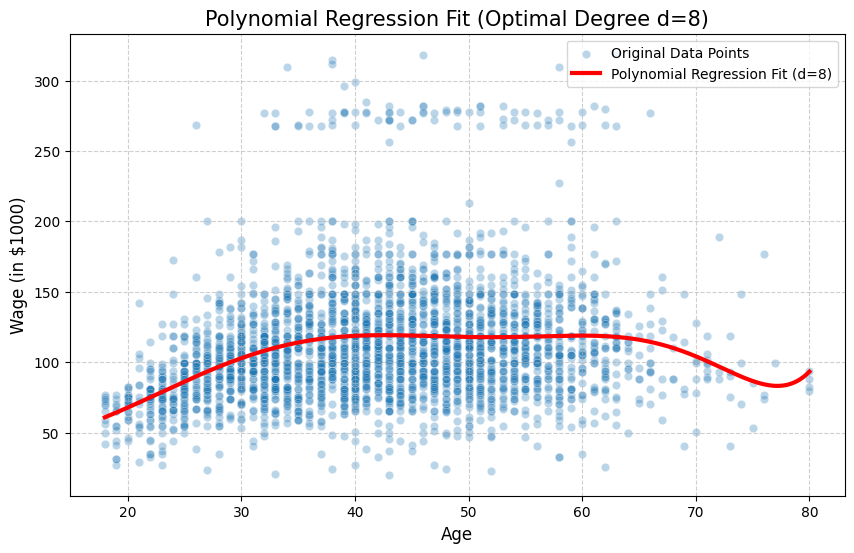

In [43]:
final_poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=optimal_degree)),
    ('linear', LinearRegression())
])
final_poly_pipeline.fit(X, y)

age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 500).reshape(-1, 1)
wage_pred_poly = final_poly_pipeline.predict(age_grid)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='wage', data=Wage, alpha=0.3, label='Original Data Points')
plt.plot(age_grid.flatten(), wage_pred_poly, color='red', linewidth=3, label=f'Polynomial Regression Fit (d={optimal_degree})')

plt.title(f'Polynomial Regression Fit (Optimal Degree d={optimal_degree})', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Wage (in $1000)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## (b) Fit a step function to predict wage using age, and perform crossvalidation to choose the optimal number of cuts. Make a plot of the ft obtained.

In [38]:
X = Wage['age'].values.reshape(-1, 1)
y = Wage['wage'].values

cv = KFold(n_splits=10, shuffle=True, random_state=34)
num_cuts = range(1, 12)
mse_scores_step = []

for c in num_cuts:
    temp_scores = []

    _, fixed_bins = pd.cut(Wage['age'], bins=c + 1, retbins=True, include_lowest=True, right=True)

    for train_idx, test_idx in cv.split(X, y):
        Wage_train = Wage.loc[train_idx].copy()
        Wage_test = Wage.loc[test_idx].copy()

        Wage_train['age_cut'] = pd.cut(
            Wage_train['age'],
            bins=fixed_bins,
            include_lowest=True,
            right=True
        )

        Wage_test['age_cut'] = pd.cut(
            Wage_test['age'],
            bins=fixed_bins,
            include_lowest=True,
            right=True
        )

        formula = 'wage ~ C(age_cut)'
        model = ols(formula, data=Wage_train).fit()
        y_pred = model.predict(Wage_test)

        mse = np.mean((Wage_test['wage'] - y_pred)**2)
        temp_scores.append(mse)

    mse_scores_step.append(np.mean(temp_scores))

optimal_cuts_index = np.argmin(mse_scores_step)
optimal_cuts = num_cuts[optimal_cuts_index]
min_mse_step = np.min(mse_scores_step)
optimal_bins = optimal_cuts + 1

for c, mse in zip(num_cuts, mse_scores_step):
    print(f"c={c} (K={c+1}), MSE = {mse:.2f}")

print(f"\nBest: c = {optimal_cuts} (K={optimal_bins}), MSE = {min_mse_step:.2f}")

c=1 (K=2), MSE = 1733.55
c=2 (K=3), MSE = 1681.93
c=3 (K=4), MSE = 1635.12
c=4 (K=5), MSE = 1629.73
c=5 (K=6), MSE = 1622.85
c=6 (K=7), MSE = 1610.51
c=7 (K=8), MSE = 1599.36
c=8 (K=9), MSE = 1609.34
c=9 (K=10), MSE = 1603.00
c=10 (K=11), MSE = 1597.53
c=11 (K=12), MSE = 1601.17

Best: c = 10 (K=11), MSE = 1597.53


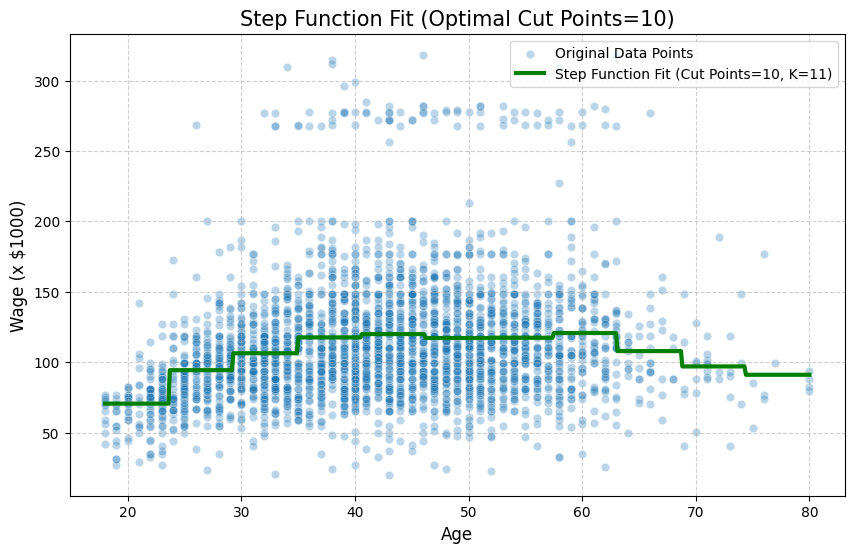

In [44]:
_, final_fixed_bins = pd.cut(Wage['age'], bins=optimal_bins, retbins=True, include_lowest=True, right=True)

Wage['age_cut_final'] = pd.cut(Wage['age'], bins=final_fixed_bins, include_lowest=True, right=True)
final_step_model = ols('wage ~ C(age_cut_final)', data=Wage).fit()

age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 500).reshape(-1, 1)
age_grid_df = pd.DataFrame({'age': age_grid.flatten()})

age_grid_df['age_cut_final'] = pd.cut(
    age_grid_df['age'],
    bins=final_fixed_bins,
    include_lowest=True,
    right=True
)

wage_pred_step = final_step_model.predict(age_grid_df)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='wage', data=Wage, alpha=0.3, label='Original Data Points')
plt.plot(age_grid.flatten(), wage_pred_step, color='green', linewidth=3, label=f'Step Function Fit (Cut Points={optimal_cuts}, K={optimal_bins})')

plt.title(f'Step Function Fit (Optimal Cut Points={optimal_cuts})', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Wage (x $1000)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()